In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from marchingband_data.run_sim import generate_training_data, system_regimes_gt
from marchingband_data.metrics import compute_regime_labeling_accuracy, get_aligned_estimate
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### Define Hyper-Parameters and Directories

In [4]:
lags = [list(range(1, i + 1)) for i in [200]]
factor_dims = [25]
seeds = [121]
true_system_regimes = np.argmax(system_regimes_gt(10,  [1227, 2840, 6128, 7392, 9553, 9680]), axis=1)

home_dir = os.path.expanduser("~")
plots_dir = f"{home_dir}/dsarf_agentformer_baseline_for_hsrdm/dsarf_on_marching/plots/"
losses_dir = f"{home_dir}/dsarf_agentformer_baseline_for_hsrdm/dsarf_on_marching/losses/"
predictions_dir = f"{home_dir}/dsarf_agentformer_baseline_for_hsrdm/dsarf_on_marching/predictions/"
results_dir = f"{home_dir}/dsarf_agentformer_baseline_for_hsrdm/dsarf_on_marching/results/"

### Define Plots

In [136]:
def original_segmentation_plot(factor_dim, lags, seed): 
    state_summary = torch.load(results_dir + f"run_{seed}_{factor_dim}_{lags[-1]}.pth")
    end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
    new_summary = []
    for v,z in zip(state_summary, end_times): 
        k = v[:z]
        new_summary.append(k)
    estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
    segment_matrix = estimated_regimes.reshape(1, -1)
    plt.figure(figsize=(15, 2))
    plt.imshow(segment_matrix, aspect='auto', cmap='tab10')
    plt.xlabel('Time')
    plt.title('Original Segmentation Plot Over Time')
    plt.yticks([]) 
    plt.colorbar(label='Segments')
    plt.savefig(plots_dir + f"original_segmentation_{seed}_{factor_dim}_{lags[-1]}.pdf")

def aligned_segmentation_plot(factor_dim, lags, seed): 
    state_summary = torch.load(results_dir + f"run_{seed}_{factor_dim}_{lags[-1]}.pth")
    end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
    new_summary = []
    for v,z in zip(state_summary, end_times): 
        k = v[:z]
        new_summary.append(k)
    estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
    aligned_matrix = get_aligned_estimate(estimated_regimes, true_system_regimes)
    segment_matrix = aligned_matrix.reshape(1, -1)

    plt.figure(figsize=(15, 2))
    plt.imshow(segment_matrix, aspect='auto', cmap='tab10')
    plt.xlabel('Time')
    plt.title('Original Segmentation Plot Over Time')
    plt.yticks([]) 
    plt.colorbar(label='Segments')
    plt.savefig(plots_dir + f"aligned_segmentation_{seed}_{factor_dim}_{lags[-1]}.pdf")

def loss_plot(factor_dim, lags, seed): 
    iters = [i for i in range(200)]
    losses = torch.load(losses_dir + f"run_{seed}_{factor_dim}_{lags[-1]}.pth")
    plt.figure(figsize=(15, 2))
    plt.plot(iters, losses)
    plt.xlabel('Iterations')
    plt.ylabel('ELBO')
    plt.title('ELBO LOSS')
    plt.savefig(plots_dir + f"loss_{seed}_{factor_dim}_{lags[-1]}.pdf")

def plot_prediction_grid(prediction_matrix): 
    x = np.arange(0, np.shape(prediction_matrix)[0])
    y = np.arange(0, np.shape(prediction_matrix)[1])
    x, y = np.meshgrid(x, y)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, prediction_matrix.T, cmap='viridis')  # Transpose if needed for orientation
    ax.set_xlabel('Lags')
    ax.set_ylabel('Factor Dimensions')
    ax.set_zlabel('NRMSE')
    plt.savefig(plots_dir + f"Prediction.pdf")
    plt.show()

def plot_accuracy_grid(accuracy_matrix): 
    x = np.arange(0, np.shape(accuracy_matrix)[0])
    y = np.arange(0, np.shape(accuracy_matrix)[1])
    x, y = np.meshgrid(x, y)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x, y, accuracy_matrix.T, cmap='viridis')  # Transpose if needed for orientation
    ax.set_xlabel('Lags')
    ax.set_ylabel('Factor Dimensions')
    ax.set_zlabel('Accuracy')
    plt.savefig(plots_dir + f"Accuracy.pdf")
    plt.show()

### Plot Individual Results

/var/folders/kl/r9wr7qsj00s1xn3byvgtczr80000gq/T/ipykernel_12052/2504176615.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_summary = torch.load(f'/Users/kgili/DSA

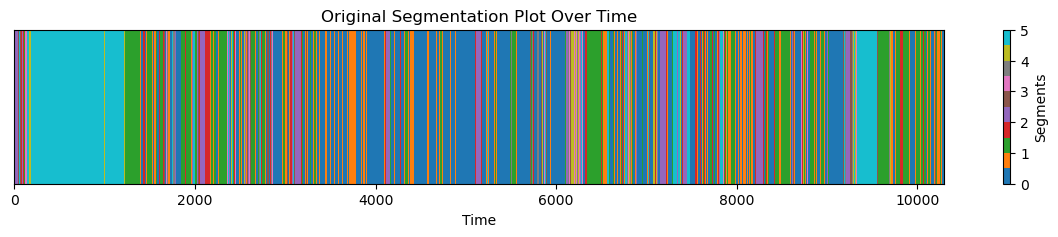

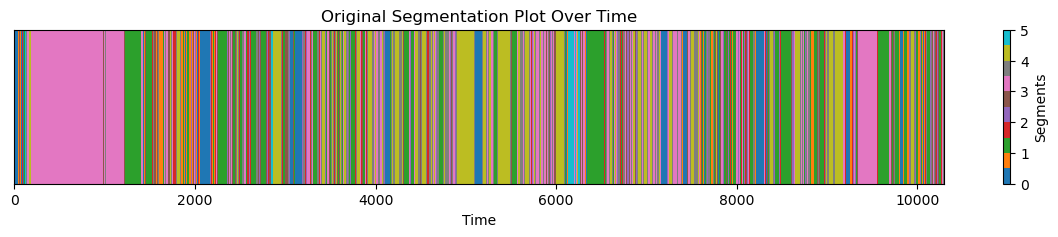

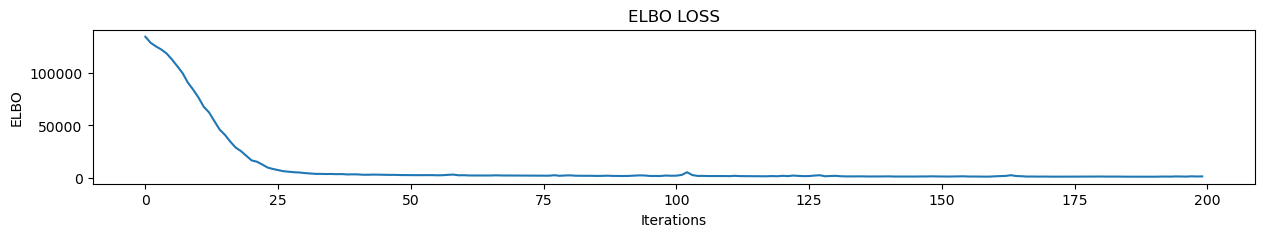

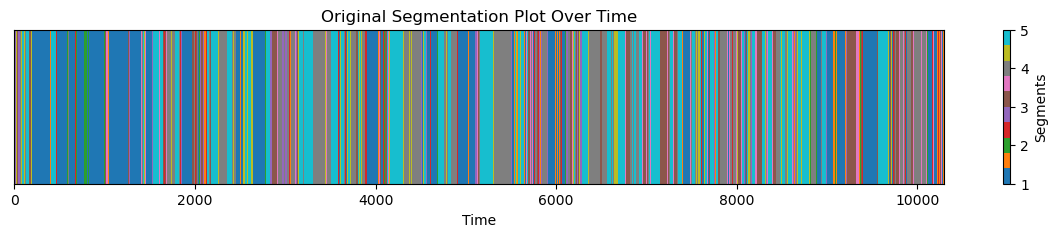

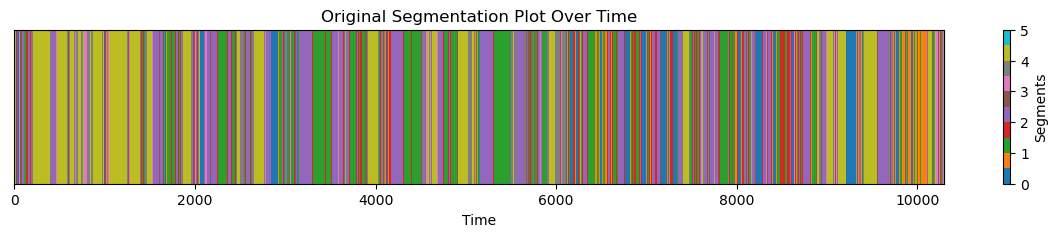

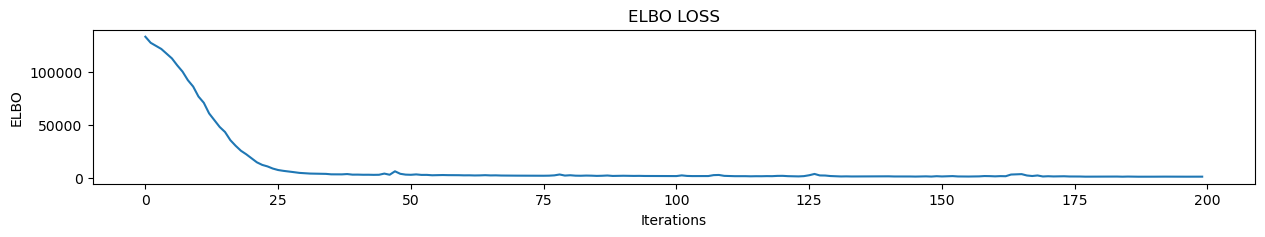

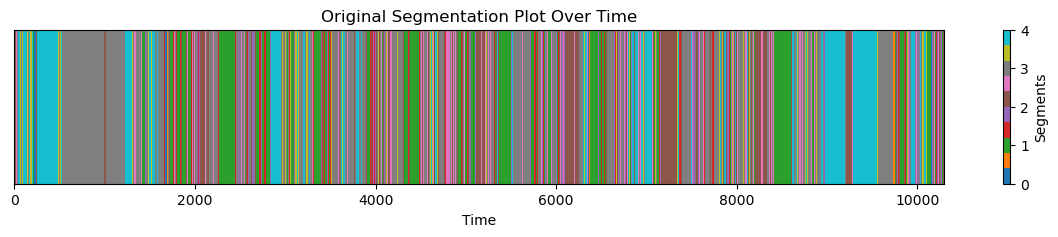

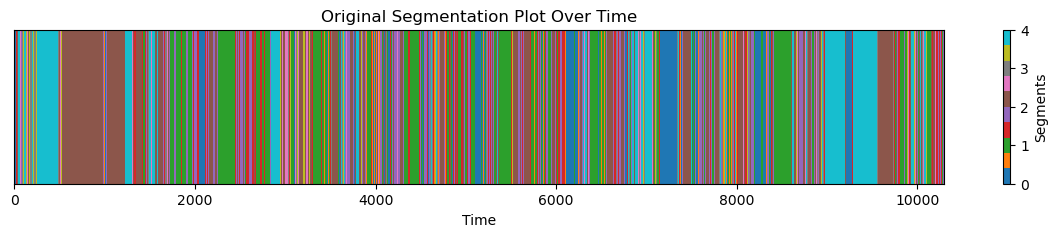

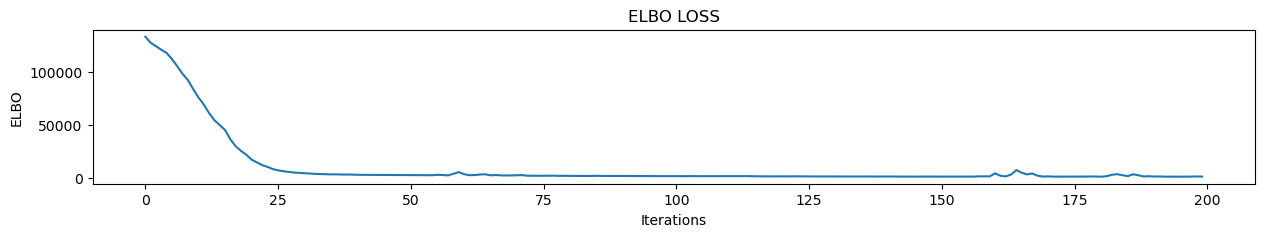

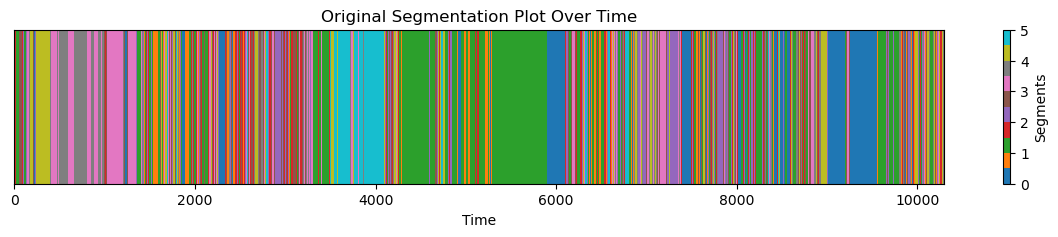

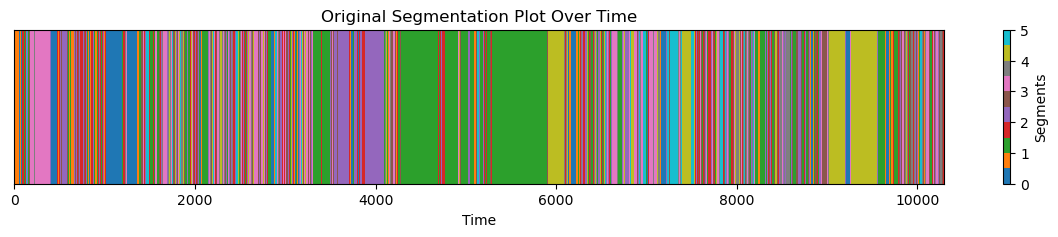

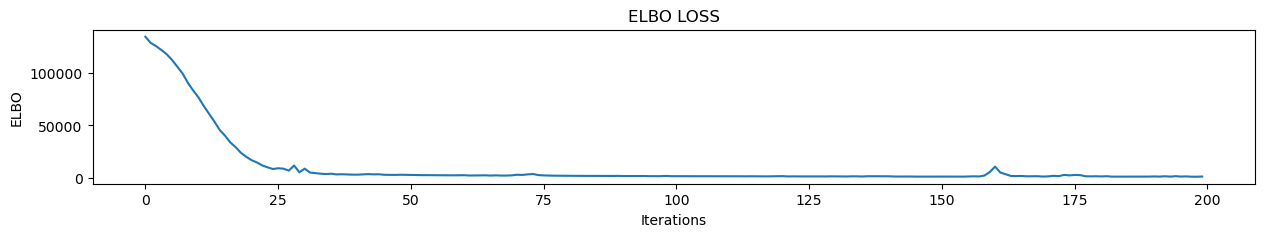

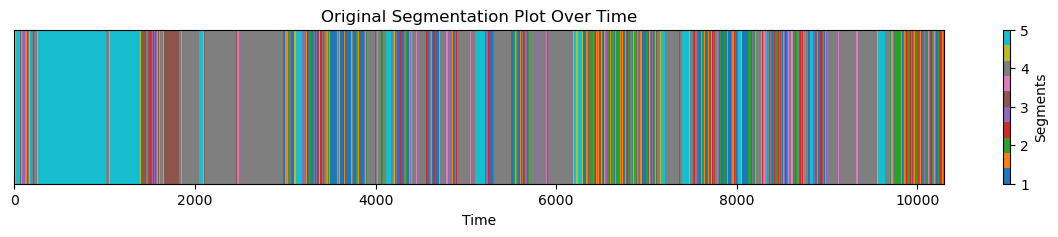

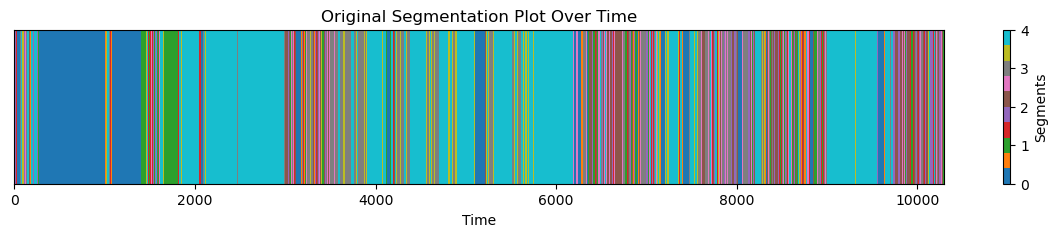

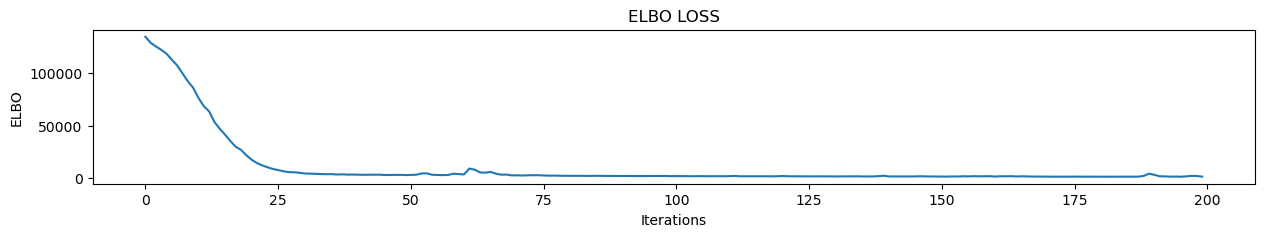

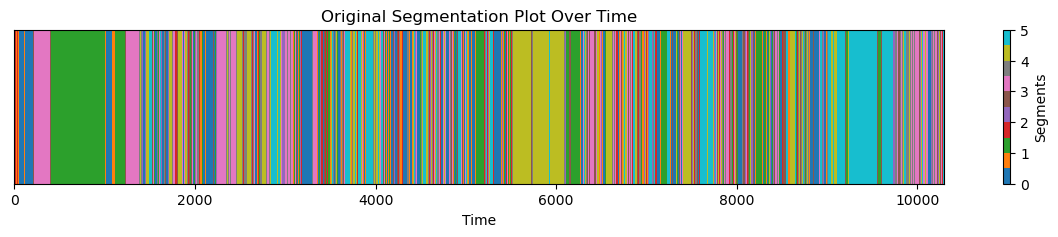

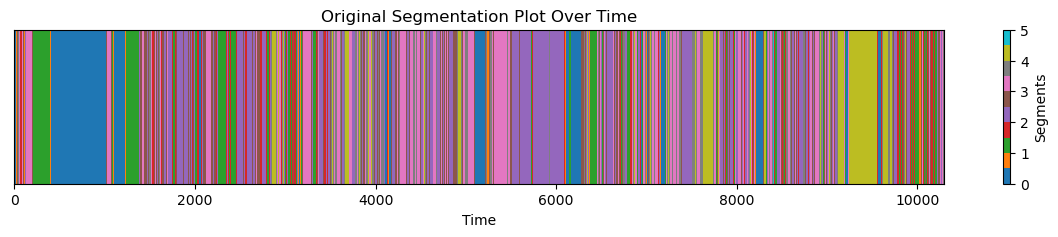

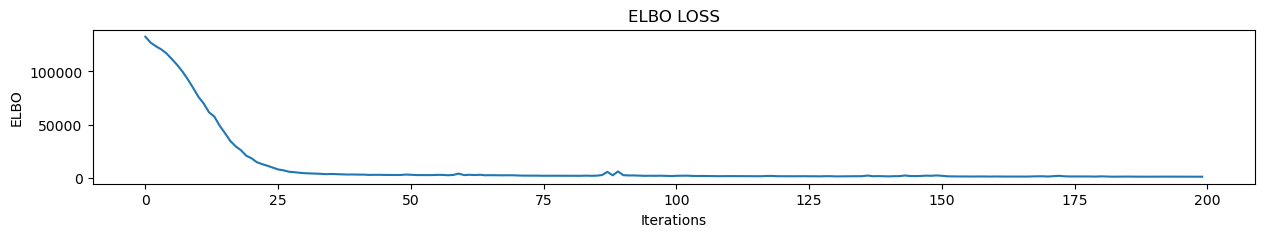

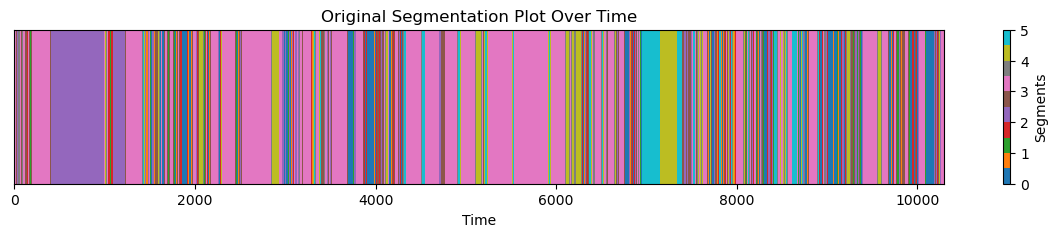

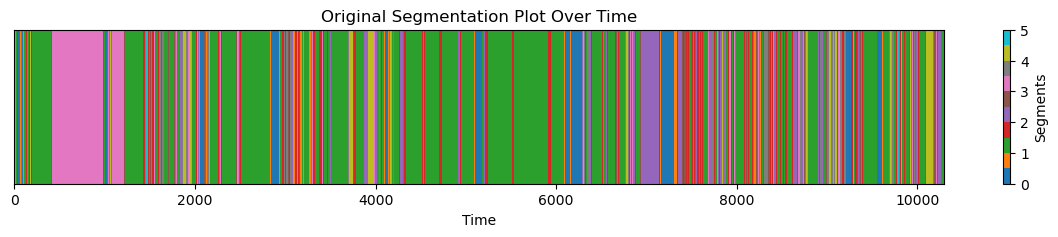

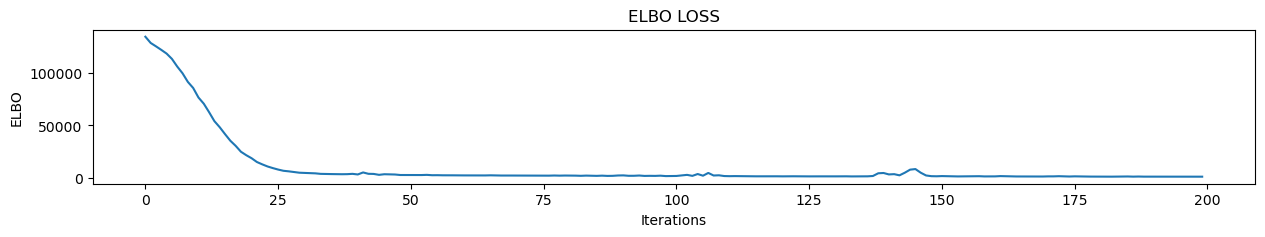

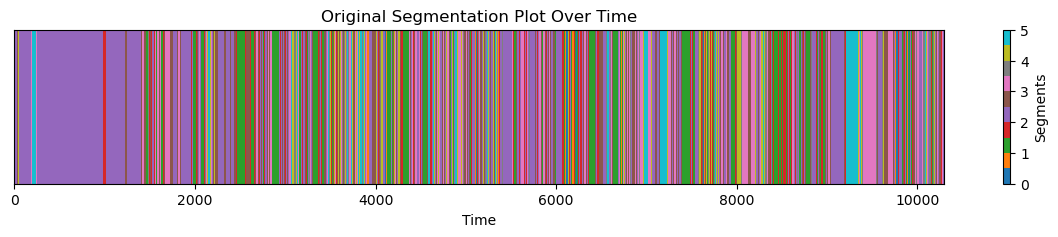

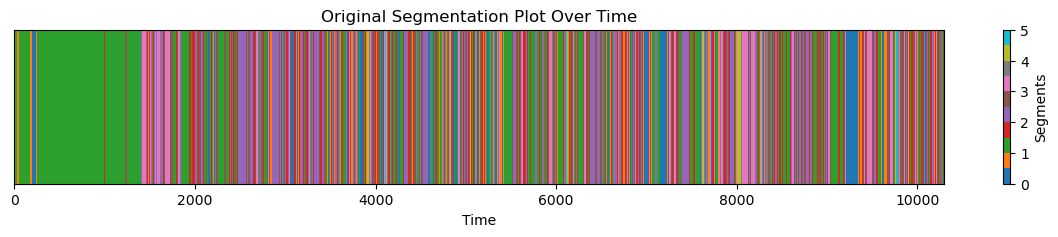

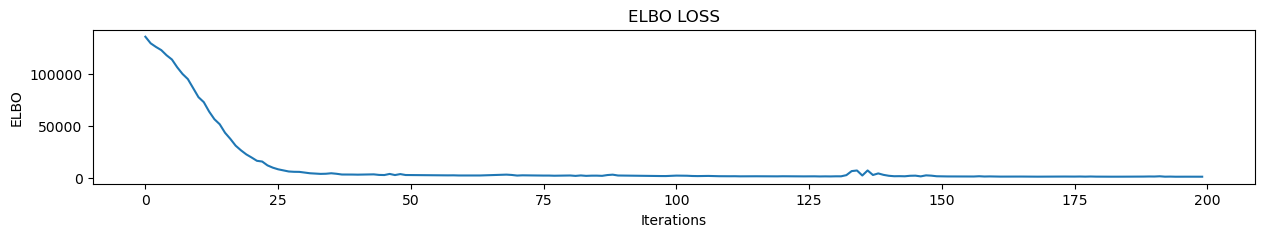

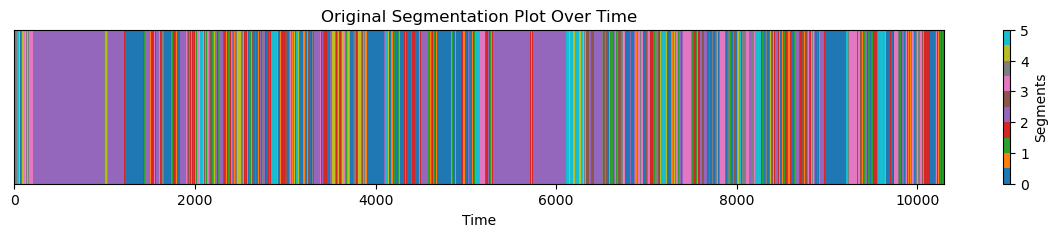

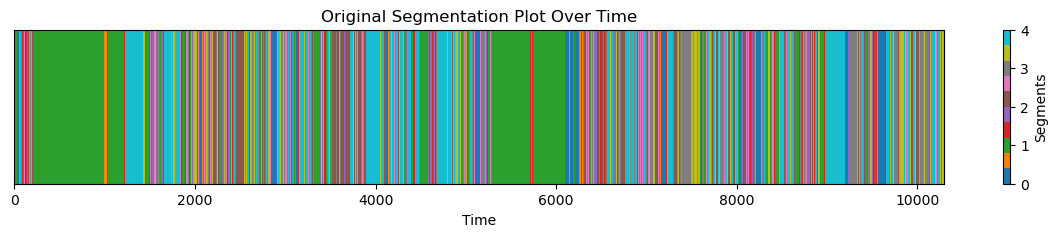

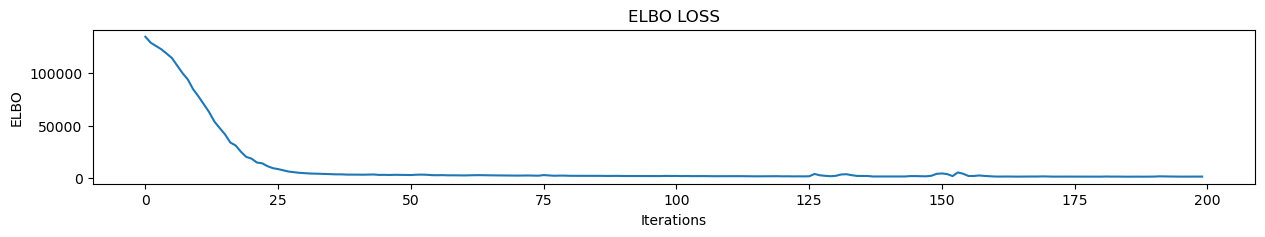

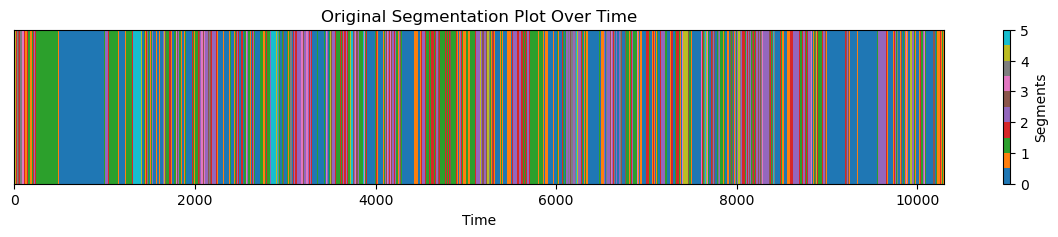

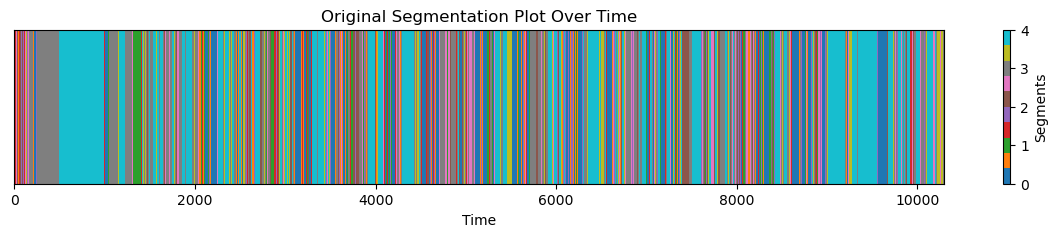

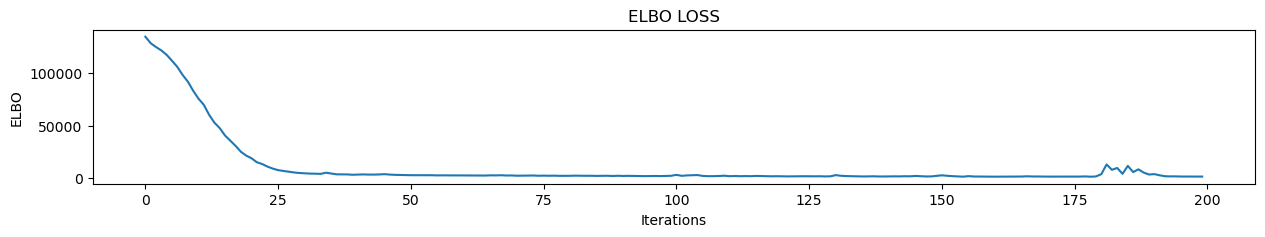

In [144]:
for seed in seeds: 
    for i, L in enumerate(lags): 
        for j, factor_dim in enumerate(factor_dims): 
            original_segmentation_plot(factor_dim, L, seed)
            aligned_segmentation_plot(factor_dim, L, seed)
            loss_plot(factor_dim, L, seed)


### Get System-State Classification Accuracy and Data Fit Accuracy 

In [145]:
accuracy_matrix = np.zeros((len(factor_dims), len(lags)))
prediction_matrix = np.zeros((len(factor_dims), len(lags)))

accuracy_matrix = np.zeros(len(seeds))
prediction_matrix = np.zeros(len(seeds))

for s, seed in enumerate(seeds): 
    for i, L in enumerate(lags): 
        for j, factor_dim in enumerate(factor_dims): 
            state_summary = torch.load(results_dir + f"run_{seed}_{factor_dim}_{L[-1]}.pth")
            error_summary = torch.load(predictions_dir + f"run_{seed}_{factor_dim}_{L[-1]}.pth")
            end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
            new_summary = []
            for v,z in zip(state_summary, end_times): 
                k = v[:z]
                new_summary.append(k)
            estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
            pct_correct_system = compute_regime_labeling_accuracy(estimated_regimes, true_system_regimes)
            accuracy_matrix[s]  = pct_correct_system
            prediction_matrix[s] = list(error_summary.values())[0]

[0.33126214 0.38873786 0.35504854 0.27902913 0.3        0.3192233
 0.32106796 0.29087379 0.31       0.34398058]
[ 9.4345953   9.23183933  9.45354162 10.20145484  9.5754873   9.19464995
  9.38827611  9.80429996  9.7908312   9.56070796]


/var/folders/kl/r9wr7qsj00s1xn3byvgtczr80000gq/T/ipykernel_12052/3457327149.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_summary = torch.load(f'/Users/kgili/DS

### Final Paper Plot for Best Hyper-Param Seed

/var/folders/kl/r9wr7qsj00s1xn3byvgtczr80000gq/T/ipykernel_12327/1944202171.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_summary = torch.load(f'/Users/kgili/DSA

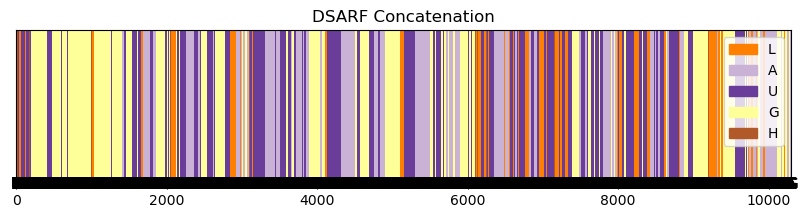

In [18]:
state_summary = torch.load(results_dir + f"run_121_25_{lags[0][-1]}.pth")
end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
new_summary = []
for v,z in zip(state_summary, end_times): 
    k = v[:z]
    new_summary.append(k)
estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
aligned_matrix = get_aligned_estimate(estimated_regimes, true_system_regimes)
segment_matrix = aligned_matrix.reshape(1, -1)
segment_matrix  = segment_matrix[0]

letters=["L", "A", "U", "G", "H", "C"]
colors=['#ff7f00','#cab2d6','#6a3d9a','#ffff99','#b15928','#a6cee3']

unique_values = np.unique(segment_matrix)
    
if len(unique_values) > len(colors):
    raise ValueError("More unique values than colors available. Please provide additional colors.")

color_map = dict(zip(unique_values, colors[:len(unique_values)]))
letter_map = dict(zip(unique_values, letters[:len(unique_values)]))
    
fig, ax = plt.subplots(figsize=(10, 2))

for i, value in enumerate(segment_matrix):
    # Draw the rectangle segment
    rect = patches.Rectangle((i, -1), 1, 2, linewidth=0, edgecolor='none', facecolor=color_map[value])
    ax.add_patch(rect)
    # Add text to the middle of the rectangle
    ax.text(i + 0.5, 0, letter_map[value], ha='center', va='center', fontsize=12, color='black')

# Customize plot
ax.set_xlim(0, len(segment_matrix))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('DSARF Concatenation')

# Add a legend
handles = [patches.Patch(color=color_map[val], label=f'{letter_map[val]}') for val in unique_values]
ax.legend(handles=handles, loc='upper right')

plt.show()



### Plot Ground Truth System State Classification

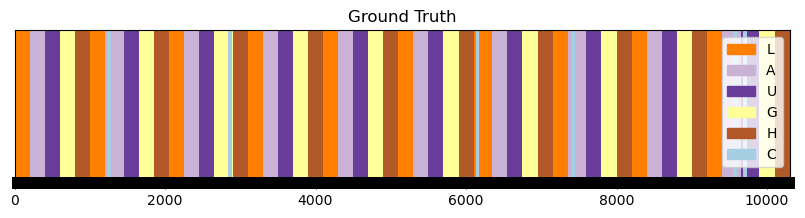

In [5]:

letters=["L", "A", "U", "G", "H", "C"]
colors=['#ff7f00','#cab2d6','#6a3d9a','#ffff99','#b15928','#a6cee3']

unique_values = np.unique(true_system_regimes)
    
if len(unique_values) > len(colors):
    raise ValueError("More unique values than colors available. Please provide additional colors.")

color_map = dict(zip(unique_values, colors[:len(unique_values)]))
letter_map = dict(zip(unique_values, letters[:len(unique_values)]))
    
fig, ax = plt.subplots(figsize=(10, 2))

for i, value in enumerate(true_system_regimes):
    # Draw the rectangle segment
    rect = patches.Rectangle((i, -1), 1, 2, linewidth=0, edgecolor='none', facecolor=color_map[value])
    ax.add_patch(rect)
    # Add text to the middle of the rectangle
    ax.text(i + 0.5, 0, letter_map[value], ha='center', va='center', fontsize=12, color='black')

# Customize plot
ax.set_xlim(0, len(true_system_regimes))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('Ground Truth')

# Add a legend
handles = [patches.Patch(color=color_map[val], label=f'{letter_map[val]}') for val in unique_values]
ax.legend(handles=handles, loc='upper right')

plt.show()